# Backpropagation
Based on chapter 7.3.3 of the book by Rojas (https://www.inf.fu-berlin.de/inst/ag-ki/rojas_home/documents/1996/NeuralNetworks/neuron.pdf), I will implement the "matrix way" of implementing backpropagation.

I will implement a two-layer artificial neural network with two input neurons and one output neuron. The goal is to learn the [XOR gate](https://en.wikipedia.org/wiki/XOR_gate), as well as training my network on the MNIST dataset and state the model accuracy (or the model error) for the training and test sets.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.datasets as datasets
import torch

In [6]:
# input 
X = [[0,0],[0,1],[1,0],[1,1]]

# output
y = [[0],[1],[1],[0]]

class untrained_neuralnetwork:
    def __init__(self):
        self.input = 2    
        self.hidden = 4 
        self.output = 1  
    
        # initialize the weights randomly
        self.layer1_w = np.random.rand(self.input, self.hidden)
        print("Random weights in layer 1\n", self.layer1_w)
        self.layer2_w = np.random.rand(self.hidden, self.output)
        print("Random weights in layer 2\n", self.layer2_w) 
    
    def feedforward(self):
        # dot product of X and the weight matrix
        self.result1 = np.dot(X, self.layer1_w)
        self.activation1 = self.activation(self.result1)
        
        self.result2 = np.dot(self.activation1, self.layer2_w)
        self.activation2 = self.activation(self.result2)
        return self.result2
    
    def activation(self, x):   # sigmoid function
        return 1/(1+np.exp(-x))

print("Initialization:")
model = untrained_neuralnetwork()
print("*"*50)
model.feedforward()

# Calculate the loss for each training sample the untrained neural network (Mean squared error)
error = 0
for i in range(len(X)):
    error += (y[i]-model.activation2[i])**2
print("Loss:", error / len(X))

Initialization:
Random weights in layer 1
 [[0.38687815 0.8121309  0.14397139 0.94532306]
 [0.649734   0.63666733 0.40938656 0.10069498]]
Random weights in layer 2
 [[0.98180635]
 [0.90453036]
 [0.95234664]
 [0.01900065]]
**************************************************
Loss: [0.37056785]


Implementation of Backpropagation and optimisation of the weights of the neural network using the XOR training set: 

### x, y
(0,0), 0 

(0,1), 1

(1,0), 1

(1,1), 0

[[0.03976434]] [[0.97340604]] [[0.01720766]] [[0.97136702]]


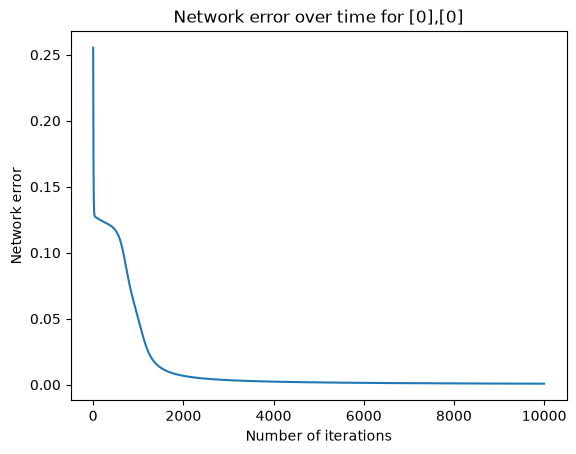

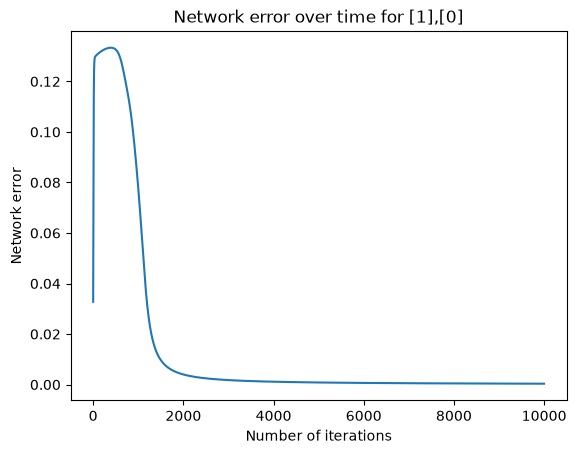

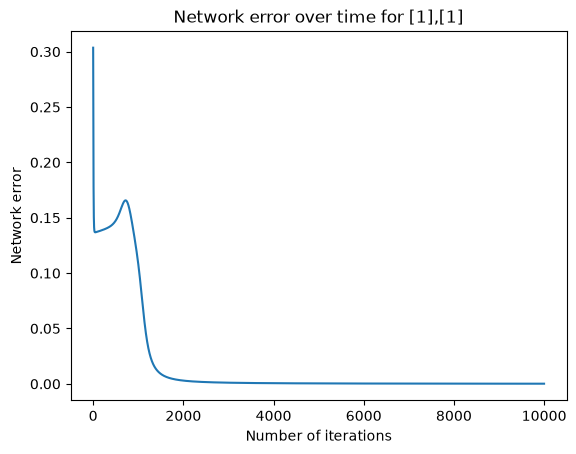

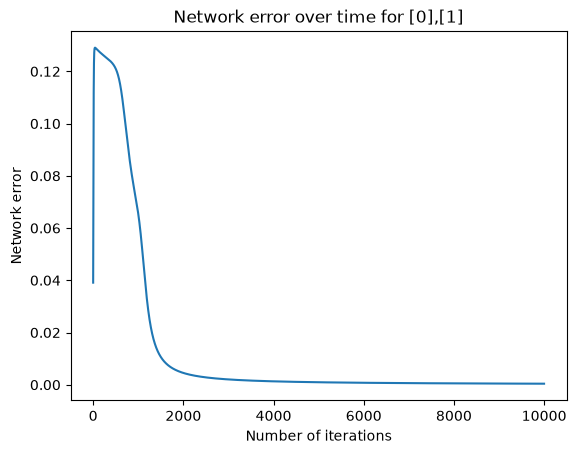

In [3]:
def sig(x):
    return 1/(1 + np.exp(-x)) 
def sig_deriv(x):
    return x*(1-x)

class Net:
    def __init__(self, inp_nr, out_nr):
        self.inp_nr = inp_nr
        self.out_nr = out_nr
        self.hidden_layers_nr = 4 # 1
        # nr of neurons in hidden layer = 4
        self.o_1 = None
        self.o_2 = None
        self.W_1 = np.random.rand(4,2)
        self.W_2 = np.random.rand(1,4)
        self.D_1 = np.zeros((4,4))
        self.D_2 = np.zeros(1)
        self.e = 0
        self.lam = 0.5
    
    def forward(self,v):
        #print(self.W_1)
        #print(v)
        self.o_1 = sig(np.dot(self.W_1,v))   
        d_1_array= sig_deriv(self.o_1)          
        np.fill_diagonal(self.D_1, d_1_array)  
        
        self.o_2 = sig(np.matmul(self.W_2,self.o_1)) 
        d_2_array = sig_deriv(self.o_2)
        self.D_2 = d_2_array

        return self.o_2
    
    def backward(self,x,t):
        global loss
        loss = 1/2 * (self.o_2 - t)**2
        delta_2 = self.D_2*(self.o_2-t)
        res_W_2 = self.W_2.reshape(-1,1)
        #print(self.W_2)

        delta_1 = np.matmul(self.D_1,res_W_2)*delta_2
        dW_2 = -self.lam*delta_2*self.o_1
        self.W_2 = self.W_2 + dW_2.reshape(1,-1)     
        res_x = x.reshape(-1,2)
        dW_1 = -self.lam*delta_1*res_x
        self.W_1 = self.W_1 + dW_1                  
    
net = Net(2,1)
v_1= np.array([[0],[0]])   
v_2= np.array([[1],[0]])
v_3= np.array([[1],[1]])
v_4= np.array([[0],[1]])
v1_loss = []
v2_loss = []
v3_loss = []
v4_loss = []

N = 10000
for i in range(N):
    out_1 = net.forward(v_1)
    net.backward(v_1,0)
    v1_loss.append(loss)
    out_2 = net.forward(v_2)
    net.backward(v_2,1)
    v2_loss.append(loss)
    out_3 = net.forward(v_3)
    net.backward(v_3,0)
    v3_loss.append(loss)
    out_4 = net.forward(v_4)
    net.backward(v_4,1)
    v4_loss.append(loss)

print(out_1,out_2, out_3, out_4)

arr = ["[0],[0]", "[1],[0]", "[1],[1]", "[0],[1]"]
for i in range(1,5):
    exec(f'loss_values = np.concatenate(v{i}_loss).ravel().tolist()')
    X = [i for i in range(0,N)]  
    y = loss_values
    plt.figure()
    exec(f'plt.title("Network error over time for " + arr[{i-1}])')
    plt.xlabel("Number of iterations")
    plt.ylabel("Network error")
    plt.plot(X, y)

### MNIST


In [4]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=None)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=None)
images = mnist_train.data          # torch.uint8, shape [60000, 28, 28]
ground_truth = mnist_train.targets # torch.int64, shape [60000]

print(images.shape)
print(ground_truth.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


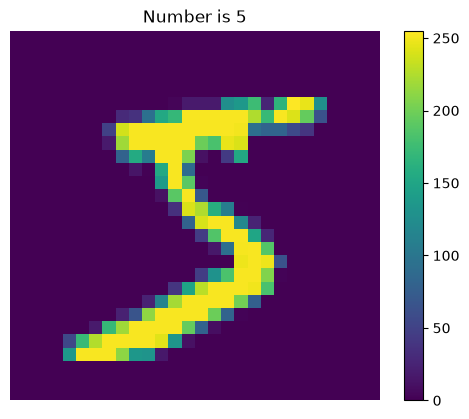

In [5]:
plt.imshow(images[0])
plt.title(f"Number is {ground_truth[0]}")
plt.colorbar()
plt.axis("off")
plt.show()

In [21]:
def sig(z):
    return 1 / (1 + np.exp(-z))

class Net:
    def __init__(self, inp_nr, hid_nr, out_nr, lam=0.1):
        self.W_1 = np.random.randn(hid_nr, inp_nr) * np.sqrt(1/inp_nr)
        self.b_1 = np.zeros(hid_nr)
        self.W_2 = np.random.randn(out_nr, hid_nr) * np.sqrt(1/hid_nr)
        self.b_2 = np.zeros(out_nr)
        self.lam = lam

    def forward(self, x):
        self.x   = x                                   # (784,)
        self.o_1 = sig(self.W_1 @ x + self.b_1)        # (hid,)
        self.o_2 = sig(self.W_2 @ self.o_1 + self.b_2) # (10,)
        return self.o_2

    def backward(self, t):
        delta_2 = (self.o_2 - t) * self.o_2 * (1 - self.o_2)
        delta_1 = (self.W_2.T @ delta_2) * self.o_1 * (1 - self.o_1)

        self.W_2 -= self.lam * np.outer(delta_2, self.o_1)
        self.b_2 -= self.lam * delta_2
        self.W_1 -= self.lam * np.outer(delta_1, self.x)
        self.b_1 -= self.lam * delta_1

        return 0.5 * np.sum((self.o_2 - t)**2)

X = images.numpy().reshape(len(images), -1).astype(np.float64) / 255.0
Y = np.eye(10)[ground_truth.numpy()]

In [27]:
net = Net(784, 30, 10)
avg_network_loss = []
N = 200

for epoch in range(N):
    total = 0.0
    order = np.random.permutation(len(X))     # shuffling matters
    for j in order:
        net.forward(X[j])
        total += net.backward(Y[j])
    avg_network_loss.append(total / len(X))
    if epoch % 10 ==0:
        print(epoch, avg_network_loss[-1])

0 0.0905965088814485
10 0.027816584758632728
20 0.02215462770794775
30 0.018678290115377468
40 0.0165541274407391
50 0.014798349487407724
60 0.013636153052209204
70 0.012274159201310857
80 0.011366681203277176
90 0.010674536257016237
100 0.01004454232516977
110 0.009465282217849749
120 0.00916171166115365
130 0.008781282521966508
140 0.008652604404475114
150 0.008281708547331386
160 0.008176651863636409
170 0.008011666037557324
180 0.007882028073887716
190 0.007755416661486961


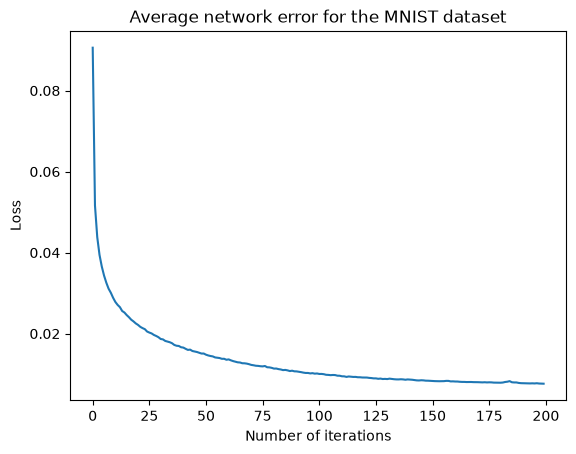

In [28]:
X = [i for i in range(0,N)]
y = avg_network_loss

plt.figure()
plt.title("Average network error for the MNIST dataset")
plt.xlabel("Number of iterations")
plt.ylabel("Loss")
plt.plot(X, y)